# EDA - Customer Lifetime Value Analysis (CLV)

# Ask

# Prepare

In [12]:
# Import nescessary libraries for EDA

from pathlib import Path # lib for handling path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
notebook_dir = Path(__file__).parent if '__file__' in dir() else Path.cwd()

path_raw_data  = notebook_dir / '..' / 'data' / 'raw'  / 'df_raw.csv'
path_clean_data = notebook_dir / '..' / 'data' / 'clean' / 'df_clean.csv'

df_raw = pd.read_csv(path_raw_data, encoding="ISO-8859-1")

In [ ]:
df_clean = df_raw.copy()

# Clean the formatting
path_processed = notebook_dir / '..' / 'data' / 'processed' / 'data.csv'
path_processed.parent.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(path_processed, index=False, encoding='utf-8')

In [15]:
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [16]:
# The shape of df_raw (rows and column)
df_raw.shape

(541909, 8)

Data has 541909 rows and 8 columns

# Process

## Missing data

In [17]:
df_raw.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing data
- `Description`: 1454
- `CustormerID`: 135080 or 24.93% missing value (135080 / 135080 * 100 = 24.93%)

The significance missing value of `CustomerID` could lead to data bias or noise. To keep this clean, we will remove them.

In [18]:
df_clean = df_clean[df_clean['CustomerID'].notna()]

In [19]:
# Check again after drop the null

df_clean.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

## Duplicated Data

In [20]:
df_clean.duplicated().sum()

np.int64(5225)

In [21]:
# Remove duplicate df_clean

df_clean.drop_duplicates(inplace=True)

## Converting Data type

In [22]:
df_clean.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

`InvoiceDate` is currently string. Need to convert into date. `CustomerID` suppose to be a whole number which mean integer

In [23]:
# Convert string to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [24]:
# Convert float to integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int, errors = 'ignore')

## Handle Cancelled transactions

In many e-commerce datasets, an InvoiceNo that starts with or is exactly 'C' represents a cancellation or a return.

In [25]:
# Filter out the 'C' which is 'Cancelled' order

df_clean = df_clean[df_clean['InvoiceNo'].apply(lambda x : x[0]) != 'C']

# Analzye (EDA)

## Custormer Lifetime Value (CLV)

**CLV = ((Average Order Value x Purchase Frequency) / Churn Rate) x Profit Margin**

In [26]:
# Calculate total purchase

df_clean['total_purchase'] = df_clean['UnitPrice'] * df_clean['Quantity']

In [27]:
data_group = df_clean.groupby('CustomerID', as_index=False).agg({
  'total_purchase':'sum', 'InvoiceNo':'count', 'Country':'min', 'InvoiceDate':lambda date:(max(date) - min(date)).days}).rename(
    columns = {'InvoiceNo':'num_transactions', 'InvoiceDate':'days'}
  )

### 1. Calculate Average Order Value

In [28]:
data_group['avg_order_value'] = data_group['total_purchase'] / data_group['num_transactions']

In [29]:
data_group.head()

,CustomerID,total_purchase,num_transactions,Country,days,avg_order_value
0,12346,77183.60,1,United Kingdom,0,77183.600000
1,12347,4310.00,182,Iceland,365,23.681319
2,12348,1797.24,31,Finland,282,57.975484
3,12349,1757.55,73,Italy,0,24.076027
4,12350,334.40,17,Norway,0,19.670588


### 2. Calculate Purchase Frequency

In [30]:
purchase_frequency = sum(data_group['num_transactions']) / data_group.shape[0]

### 3. Calculate Repeat Rate and Churn Rate 

In [31]:
# Calculate Repeat Rate
repeat_rate = len(data_group[data_group['num_transactions'] >= 2]) / len(data_group)
round(repeat_rate * 100.0, 2)

98.34

The Percentage of Repeat Rate is `98.34%`

**Retention Churn (The "One-and-Done" Rate)**

*Churn Rate=1−Repeat Rate*

- When to use: Retail and E-commerce.
- What it tells you: "What percentage of my customers are 'One-Timers' who never came back?"

In [32]:
# Calculate Churn Rate
churn_rate = 1 - repeat_rate
round(churn_rate * 100.0, 2)

1.66

The Percentage of Churn Rate is `1.66%`

### 4. Calculate Profit Margin

Profit margin is the percentage of total sales that remains as profit. Assume our business has approximately 10% profit on the total sales

In [33]:
data_group['profit_margin'] = data_group['total_purchase'] * 0.1 

### 5. Calculate Custormer Lifetime Value (CLV)

In [34]:
churn_rate

0.016593685180917306

In [35]:
# CLV = ((Average Order Value x Purchase Frequency) / Churn Rate) x Profit Margin

data_group['CLV'] = (data_group['avg_order_value'] * purchase_frequency) / churn_rate
data_group['CLV'] = data_group['CLV'] * 0.10 # profit margin
data_group['CLV'] = data_group['CLV'].apply(lambda x: '{:.2f}'.format(x))

In [36]:
data_group.head()

,CustomerID,total_purchase,num_transactions,Country,days,avg_order_value,profit_margin,CLV
0,12346,77183.60,1,United Kingdom,0,77183.600000,7718.360,42100652.22
1,12347,4310.00,182,Iceland,365,23.681319,431.000,12917.24
2,12348,1797.24,31,Finland,282,57.975484,179.724,31623.37
3,12349,1757.55,73,Italy,0,24.076027,175.755,13132.54
4,12350,334.40,17,Norway,0,19.670588,33.440,10729.54


## Customer Segmentation (DataViz)

In [37]:
data_group_v1 = data_group

## Based on total purchase value

In [ ]:
data_group_v1 = data_group
data_group_v1['segment_purchase'] = pd.cut(data_group['total_purchase'], bins = [0, 1500, 3500, float('inf')], labels = ['Low Purchase', 'Medium Purchase', 'High Purchase'])

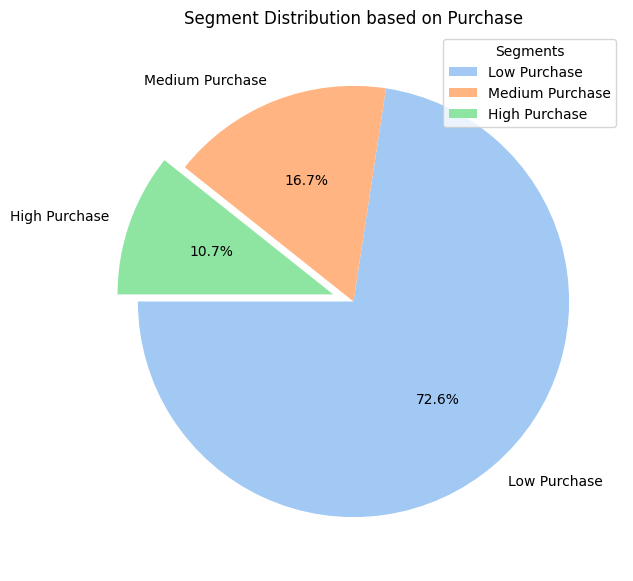

In [76]:
v1 = data_group_v1['segment_purchase'].value_counts()

colors = sns.color_palette('pastel')[0:3]
explode = [0, 0, 0.1]
plt.figure(figsize=(8, 7))
plt.pie(v1, labels=v1.index, colors=colors, autopct='%1.1f%%', startangle=180, explode=explode)
plt.title('Segment Distribution based on Purchase')
plt.legend(v1.index, title='Segments', loc='best')
plt.show()


## Customer with High Transactions

In [81]:
# Top 10 Customers

x = data_group[['CustomerID', 'num_transactions']].sort_values(by = 'num_transactions', ascending = [False]).head(10)

Text(0.5, 1.0, 'Top 10 Customers')

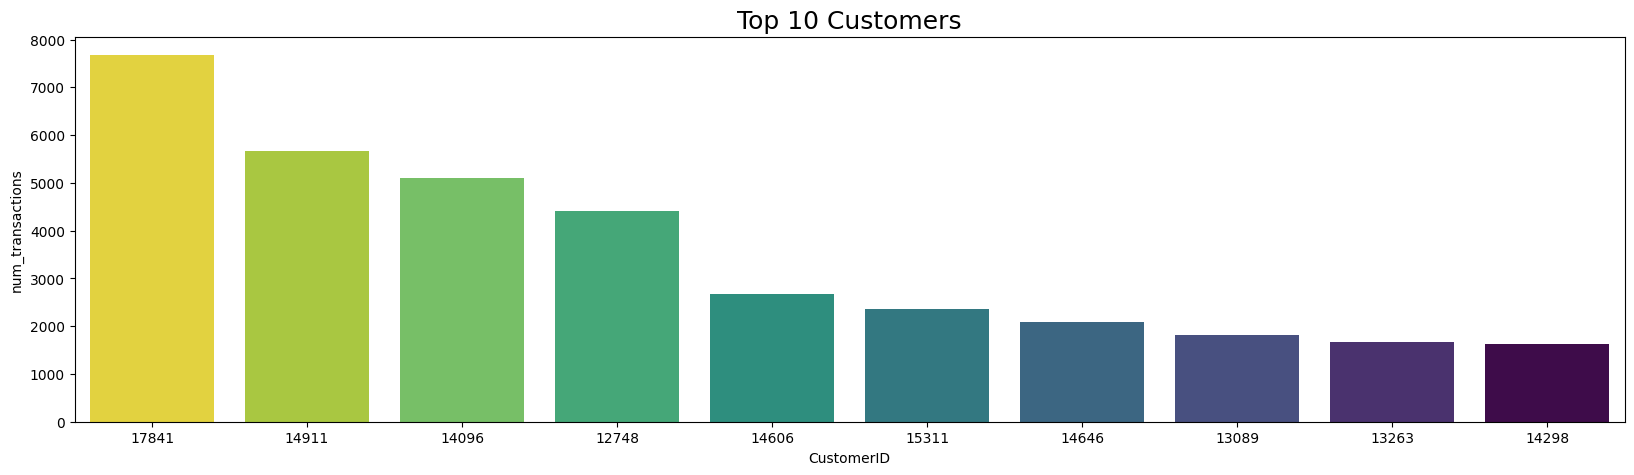

In [ ]:
plt.figure(figsize=(20, 5))

x['rank'] = range(len(x)) # Ordered the color by bar order
sns.barplot(
    data = x,
    x = 'CustomerID',
    y = 'num_transactions',
    order = x['CustomerID'],
    hue = 'rank',
    palette = 'viridis_r', # _r for reverse color palette
    legend =False
)
plt.title("Top 10 Customers", fontsize= 18)

## Geographic Analysis

### Top 10 Countries in Revenue by Purchase

In [88]:
data_group_v2 = data_group.groupby('Country', as_index= False).agg({
  'total_purchase':'sum', 'num_transactions':'sum'
  })

In [89]:
# Top 10 Countries

data_group_v2 = data_group_v2.sort_values(by = 'total_purchase', ascending = [False]).head(10)

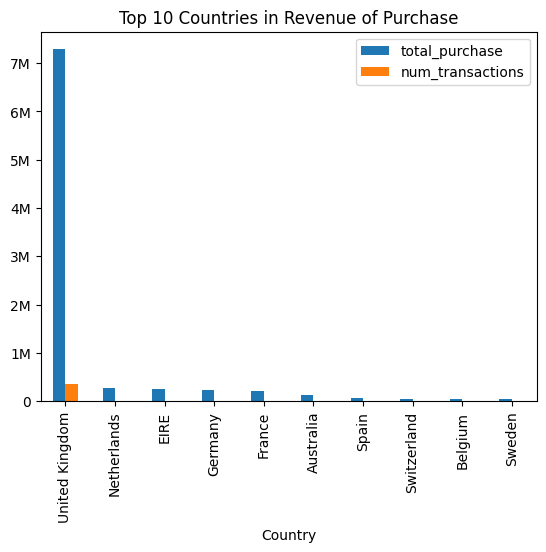

In [90]:
from matplotlib.ticker import FuncFormatter
data_group_v2.plot(kind = 'bar', x = 'Country')
def format_y_ticks(value, _):
    if value >= 1e6:
        return f'{int(value/1e6)}M'
    else:
        return int(value)

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_y_ticks))
plt.title('Top 10 Countries in Revenue of Purchase')
plt.show()

### Top 10 Countries with Most Customer

In [91]:
country = data_group['Country'].value_counts().reset_index(drop = False).head(10)
country

,Country,count
0,United Kingdom,3921
1,Germany,94
2,France,87
3,Spain,28
4,Belgium,24
5,Portugal,19
6,Switzerland,19
7,Italy,14
8,Finland,12
9,Austria,11


### Countries with High Cancelled Orders

In [92]:
df_cancel = pd.read_csv(path_raw_data, encoding='ISO-8859-1')
df_cancel = df_cancel[df_cancel['InvoiceNo'].apply(lambda x: x[0] == 'C')]
df_cancel['InvoiceDate'] = pd.to_datetime(df_cancel['InvoiceDate'])

In [ ]:
df_cancel_val = df_cancel['Country'].value_counts().nlargest(5)

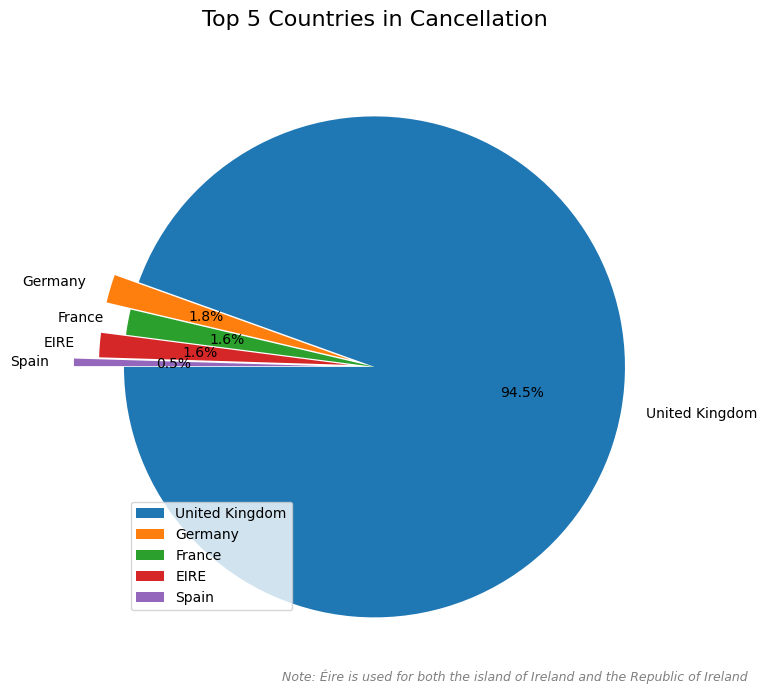

In [106]:
explode = [0, 0.1, 0, 0.1, 0.2]
colors = sns.color_palette('pastel')[0:4]

plt.figure(figsize=(8, 7))
plt.pie(df_cancel_val, labels = df_cancel_val.index, autopct ='%1.1f%%', startangle = 180, explode = explode)

plt.title('Top 5 Countries in Cancellation', fontsize = 16, pad = 20)
plt.legend(loc='lower left', bbox_to_anchor=(0.1, 0.1))

plt.figtext(0.95, 0.02, 
            'Note: Éire is used for both the island of Ireland and the Republic of Ireland', 
            horizontalalignment='right', 
            fontsize=9, 
            style='italic', 
            color='grey',
            wrap=True)

plt.tight_layout()
plt.show()

### Countries with Low Cancellation

In [105]:
df_cancel_val_low = df_cancel['Country'].value_counts().nsmallest(5)
df_cancel_val_low

Country
Saudi Arabia      10
Bahrain           19
Czech Republic    30
Brazil            32
Lithuania         35
Name: count, dtype: int64

## Time Series Analysis

### Patterns and Trends in Count of Orders

In [107]:
df_clean['InvoiceDate_d'] = df_clean['InvoiceDate'].dt.date

In [108]:
PurchaseDate_data = df_clean.groupby('InvoiceDate_d', as_index = False).agg({
  'InvoiceNo':'count', 'total_purchase':'sum'
})

<function matplotlib.pyplot.show(close=None, block=None)>

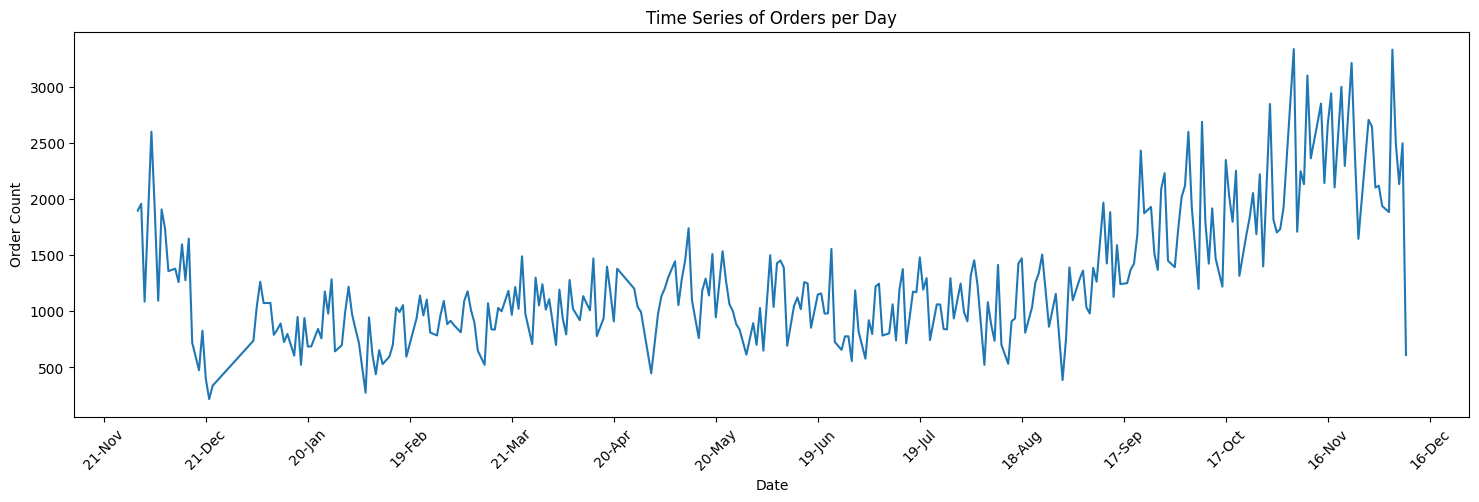

In [110]:
plt.figure(figsize = (18, 5))
sns.lineplot(data = PurchaseDate_data, x = 'InvoiceDate_d', y = 'InvoiceNo')

plt.title('Time Series of Orders per Day')
plt.xlabel('Date')
plt.ylabel('Order Count')

import matplotlib.dates as mdates
date_format = mdates.DateFormatter("%d-%b")
plt.gca().xaxis.set_major_formatter(date_format)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval = 30))
plt.xticks(rotation = 45)

plt.show

## Month vs Total Purchase

In [111]:
# Filter out the month from date
df_clean['month'] = df_clean['InvoiceDate'].dt.month_name() 
from calendar import calendar
import calendar
df_clean['month'] = pd.Categorical(df_clean['month'], categories = list(calendar.month_name)[1:])


In [112]:
month_data = df_clean.groupby('month', as_index = False)['total_purchase'].sum()
month_data

,month,total_purchase
0,January,568101.310
1,February,446084.920
2,March,594081.760
3,April,468374.331
4,May,677355.150
5,June,660046.050
6,July,598962.901
7,August,644051.040
8,September,950690.202
9,October,1035642.450


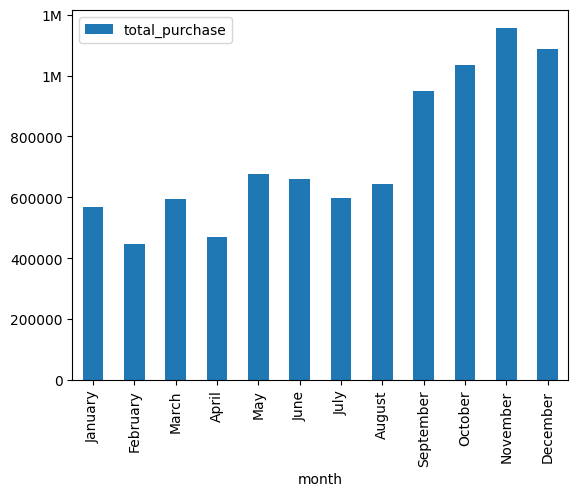

In [113]:
# Plot the graph of Month vs Total Purchase

month_data.plot(kind = 'bar', x = 'month')
from matplotlib.ticker import FuncFormatter

def format_y_ticks(value, _):
    if value >= 1e6:
        return f'{int(value/1e6)}M'
    else:
        return int(value)

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_y_ticks))
plt.show()

## Month with High Cancellation Orders

In [118]:
df_cancel['InvoiceDate'] = pd.to_datetime(df_cancel['InvoiceDate'], errors = 'coerce')
df_cancel['month'] = df_cancel['InvoiceDate'].dt.month_name()

In [119]:
month_order = list(calendar.month_name)[1:]
df_cancel['month'] = pd.Categorical(df_cancel['month'], categories=month_order, ordered=True)

In [137]:
data_month_cancel = df_cancel.groupby('month', as_index = False)['InvoiceNo'].count()

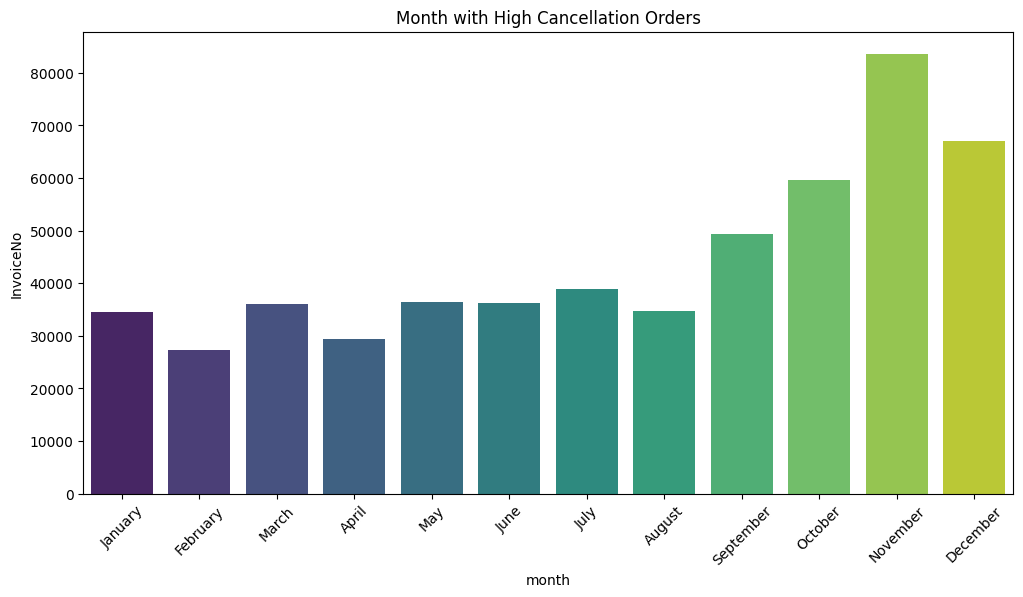

In [138]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=data_month_cancel, 
    x='month', 
    y='InvoiceNo',
    hue = 'month',
    legend = False,
    dodge = False,
    palette='viridis'
)
plt.title('Month with High Cancellation Orders')
plt.xticks(rotation=45)
plt.show()

## Stock Analysis

### Top 10 Stocks with High Orders

<positron-console-cell-139>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



<Axes: xlabel='StockCode'>

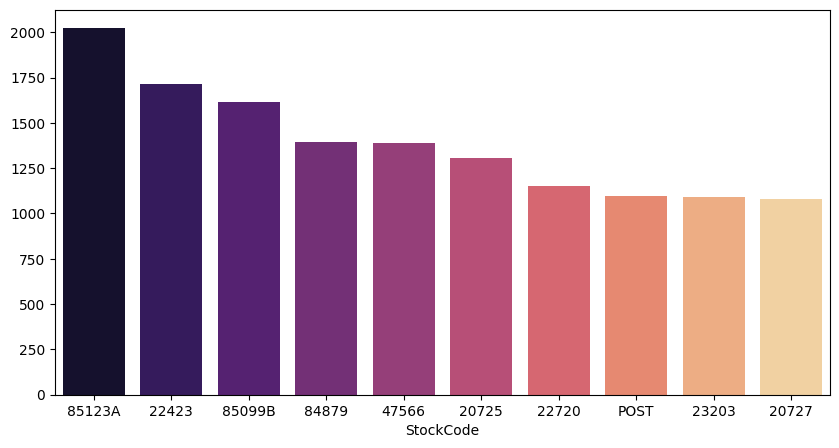

In [139]:
stockcode_counts = df_clean.StockCode.value_counts().sort_values(ascending = False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x = stockcode_counts.index, y = stockcode_counts.values, palette = 'magma')

## Description Analysis

In [141]:
# Amount of unique descriptions

df_clean['Description'].nunique()

3877

### Most Common Description

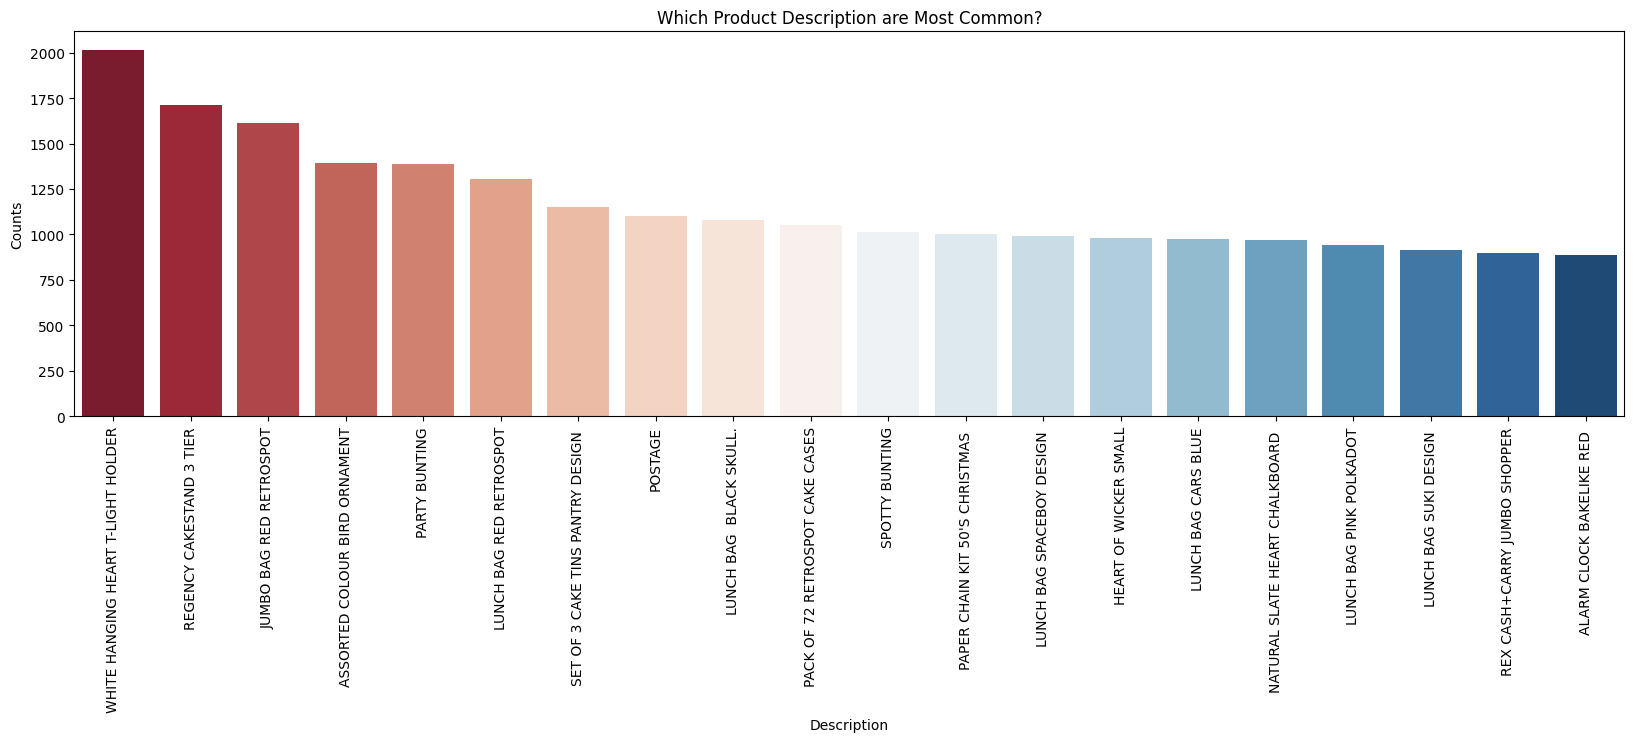

In [144]:
description_counts = df_clean.Description.value_counts().sort_values(ascending = False).head(20)
plt.figure(figsize = (20, 5))
sns.barplot(
  x = description_counts.index, 
  y = description_counts.values, 
  palette = 'RdBu',
  hue = description_counts.index,
  legend = False
  )
plt.ylabel('Counts')
plt.title('Which Product Description are Most Common?')
plt.xticks(rotation = 90)
plt.show()

### Which Product has the Highest Sales?

In [145]:
df_clean['total'] = df_clean['UnitPrice'] * df_clean['Quantity']

Text(0, 0.5, 'Product Description')

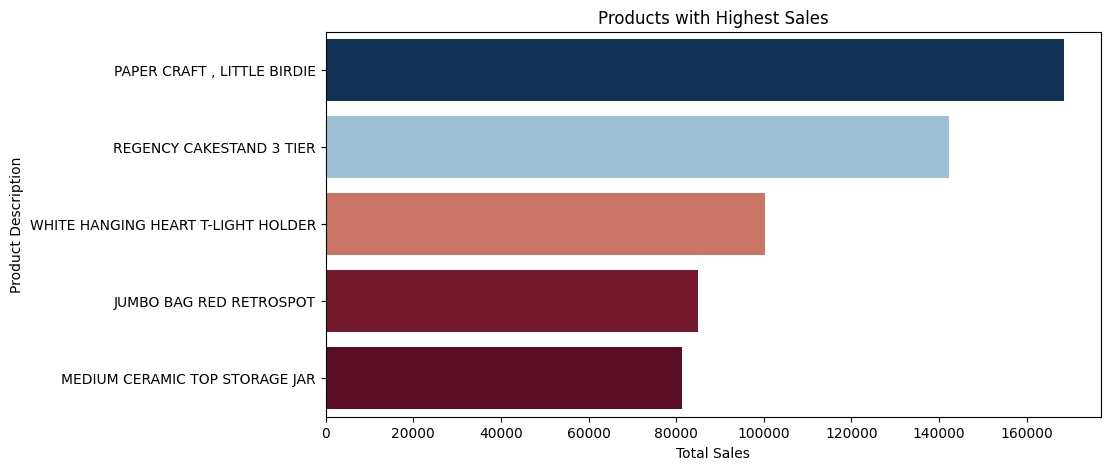

In [149]:
product_sales= df_clean.groupby('Description').agg({'total' : 'sum'}).sort_values(by = 'total' , ascending = False).reset_index(drop= False).head(5)

plt.figure(figsize = (10,5))
ad = sns.barplot(
  y = 'Description', 
  x = 'total',
  hue = 'total',
  data = product_sales,
  palette = 'RdBu',
  legend = False
  )

plt.title('Products with Highest Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Description')

# Share

# Act